# Tendance temporelle des signalements

## Objectif de ce notebook

Est-ce que les signalements de maintenance **augmentent, diminuent, ou restent stables** au fil des années ? Et surtout : si le nombre augmente, est-ce que c'est un vrai signal (les avions ont plus de problèmes), ou juste le reflet d'une flotte Airbus américaine qui grandit d'année en année ?

Comme pour le bloc précédent, on regarde **la tendance brute et la tendance normalisée côte à côte** — c'est exactement ce qui permet de répondre à cette question.

On réutilise les données déjà calculées dans le notebook 03, pas besoin de tout refaire.

In [1]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import pandas as pd

from sdr_analytics import config
from sdr_analytics.metrics import pareto_table

agg_ata = pd.read_parquet(config.CHEMIN_DONNEES_TRAITEES / "agg_ata_famille_annee.parquet")
taille_flotte = pd.read_parquet(config.CHEMIN_DONNEES_TRAITEES / "agg_taille_flotte.parquet")

# Les deux fichiers doivent couvrir exactement les mêmes années (années complètes
# uniquement) — sinon les comparaisons brut/normalisé de ce notebook seraient
# faussées. On vérifie explicitement plutôt que de supposer que c'est le cas.
assert config.ANNEE_PARTIELLE not in taille_flotte["AnneeFichier"].values, (
    "2026 (année partielle) ne devrait pas apparaître dans agg_taille_flotte.parquet"
)

print(f"{len(agg_ata)} lignes (chapitre x famille x année)")
print(f"{len(taille_flotte)} lignes (famille x année, taille de flotte)")

864 lignes (chapitre x famille x année)
31 lignes (famille x année, taille de flotte)


## 1. Tendance globale : brute vs normalisée

On additionne tous les chapitres et toutes les familles pour avoir un seul chiffre par année : le nombre total de signalements, et la taille totale de la flotte observée.

In [2]:
signalements_par_annee = agg_ata.groupby("AnneeFichier")["nb_signalements"].sum()
flotte_par_annee = taille_flotte.groupby("AnneeFichier")["nb_avions_distincts"].sum()

tendance = pd.DataFrame({
    "nb_signalements": signalements_par_annee,
    "nb_avions_distincts": flotte_par_annee,
})
tendance["taux_pour_1000_avions"] = tendance["nb_signalements"] / tendance["nb_avions_distincts"] * 1000

tendance

,nb_signalements,nb_avions_distincts,taux_pour_1000_avions
AnneeFichier,,,
2015,5939,885,6710.734463
2016,6520,976,6680.327869
2017,10088,1166,8651.801029
2018,10092,1192,8466.442953
2019,10137,1349,7514.455152
2020,7203,1269,5676.122931
2021,10697,1451,7372.157133
2022,10159,1540,6596.753247
2023,12871,1667,7721.055789


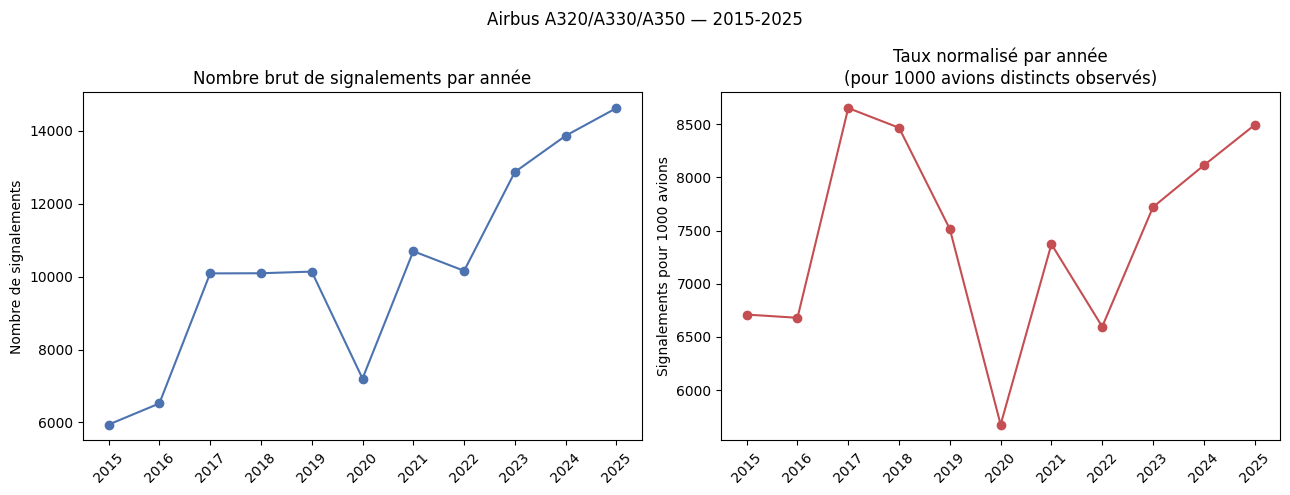

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(tendance.index, tendance["nb_signalements"], marker="o", color="#4C72B0")
ax1.set_title("Nombre brut de signalements par année")
ax1.set_ylabel("Nombre de signalements")
ax1.tick_params(axis="x", rotation=45)

ax2.plot(tendance.index, tendance["taux_pour_1000_avions"], marker="o", color="#C44E52")
ax2.set_title("Taux normalisé par année\n(pour 1000 avions distincts observés)")
ax2.set_ylabel("Signalements pour 1000 avions")
ax2.tick_params(axis="x", rotation=45)

fig.suptitle("Airbus A320/A330/A350 — 2015-2025")
fig.tight_layout()
plt.show()

**Comment lire ces deux graphiques ensemble** : à gauche, le nombre brut de signalements — il monte avec le temps. Mais est-ce que ça veut dire que les avions ont de plus en plus de problèmes ? Le graphique de droite répond à cette question en tenant compte de la taille de la flotte observée chaque année. Si les deux courbes montent de façon comparable, la hausse brute s'explique surtout par la croissance de la flotte. Si le taux normalisé monte plus vite (ou moins vite) que le brut, c'est un vrai signal indépendant de la taille de flotte.

## 2. Est-ce que la tendance est la même pour chaque famille ?

On refait le même calcul, mais séparément pour A320, A330 et A350.

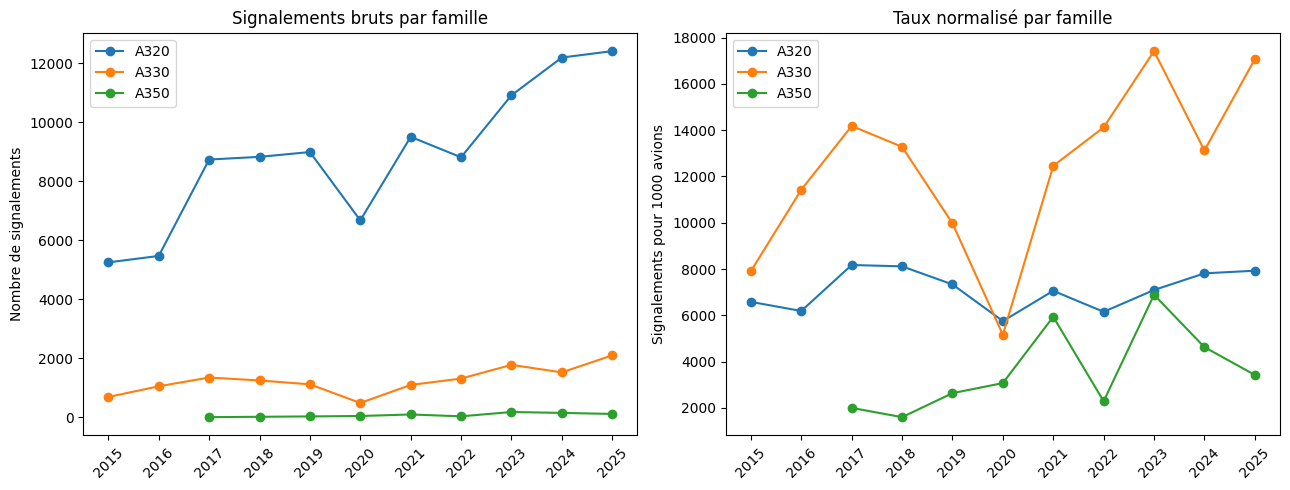

In [4]:
par_famille = agg_ata.groupby(["AnneeFichier", "famille_appareil"])["nb_signalements"].sum().reset_index()
par_famille = par_famille.merge(taille_flotte, on=["AnneeFichier", "famille_appareil"], how="left")
par_famille["taux_pour_1000_avions"] = par_famille["nb_signalements"] / par_famille["nb_avions_distincts"] * 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for famille, groupe in par_famille.groupby("famille_appareil"):
    ax1.plot(groupe["AnneeFichier"], groupe["nb_signalements"], marker="o", label=famille)
    ax2.plot(groupe["AnneeFichier"], groupe["taux_pour_1000_avions"], marker="o", label=famille)

ax1.set_title("Signalements bruts par famille")
ax1.set_ylabel("Nombre de signalements")
ax1.tick_params(axis="x", rotation=45)
ax1.legend()

ax2.set_title("Taux normalisé par famille")
ax2.set_ylabel("Signalements pour 1000 avions")
ax2.tick_params(axis="x", rotation=45)
ax2.legend()

fig.tight_layout()
plt.show()

## 3. Évolution des chapitres ATA les plus signalés

On reprend les 6 chapitres qui dominaient le classement du notebook précédent, et on regarde leur évolution année par année.

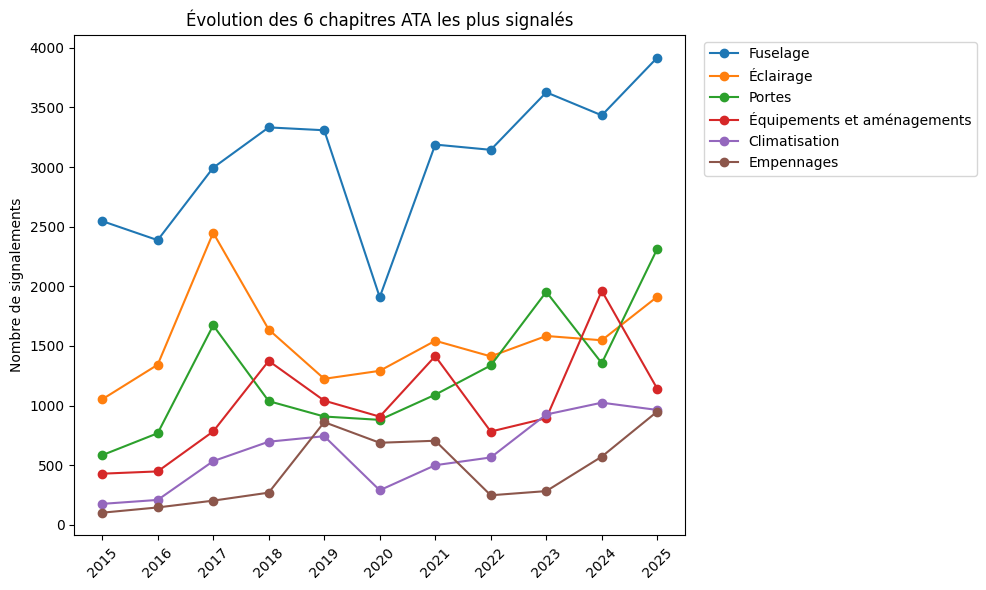

In [5]:
comptage_total_par_chapitre = agg_ata.groupby("chapitre_ata")["nb_signalements"].sum()
top6_chapitres = pareto_table(comptage_total_par_chapitre).head(6).index.tolist()

libelles = agg_ata[["chapitre_ata", "libelle_ata"]].drop_duplicates().set_index("chapitre_ata")["libelle_ata"]

evolution_top6 = (
    agg_ata[agg_ata["chapitre_ata"].isin(top6_chapitres)]
    .groupby(["AnneeFichier", "chapitre_ata"])["nb_signalements"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))
for chapitre in top6_chapitres:
    sous_ensemble = evolution_top6[evolution_top6["chapitre_ata"] == chapitre]
    plt.plot(sous_ensemble["AnneeFichier"], sous_ensemble["nb_signalements"], marker="o", label=libelles[chapitre])

plt.title("Évolution des 6 chapitres ATA les plus signalés")
plt.ylabel("Nombre de signalements")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. Variation d'une année sur l'autre

Comparaison de la dernière année complète (2025) par rapport à l'année précédente (2024), pour ces mêmes chapitres.

In [6]:
pivot_annees = evolution_top6.pivot(index="chapitre_ata", columns="AnneeFichier", values="nb_signalements")

variation = pd.DataFrame({
    "libelle": [libelles[c] for c in pivot_annees.index],
    "2024": pivot_annees["2024"],
    "2025": pivot_annees["2025"],
})
variation["variation_pct"] = (variation["2025"] - variation["2024"]) / variation["2024"] * 100
variation = variation.sort_values("variation_pct", ascending=False)

variation.round(1)

,libelle,2024,2025,variation_pct
chapitre_ata,,,,
52,Portes,1356,2315,70.7
55,Empennages,573,951,66.0
33,Éclairage,1548,1913,23.6
53,Fuselage,3433,3917,14.1
21,Climatisation,1025,964,-6.0
25,Équipements et aménagements,1962,1141,-41.8


## Ce qu'on retient

- **La hausse brute s'explique en grande partie par la croissance de la flotte** : le nombre de signalements a été multiplié par ≈2,5 entre 2015 et 2025 (5 939 → 14 624), mais la flotte observée a elle aussi presque doublé sur la même période (885 → 1 722 avions distincts). Une bonne partie de la hausse brute n'est donc pas un signe d'appareils moins fiables, mais simplement le reflet d'une flotte plus grande.
- **Le taux normalisé ne montre pas de tendance nette à la hausse ou à la baisse** — il oscille plutôt entre 5 700 et 8 650 signalements pour 1000 avions selon les années, sans direction claire sur 10 ans.
- **2020 se démarque nettement** : c'est l'année où le taux normalisé est le plus bas (5 676). Ça correspond à l'année Covid — moins d'avions en vol, donc moins d'occasions de détecter et signaler un problème. Une baisse de taux ne veut pas toujours dire "moins de pannes", ça peut aussi vouloir dire "moins d'exposition".
- **Sur la dernière année (2024 → 2025)**, les chapitres "Portes" (+71%) et "Empennages" (+66%) progressent nettement, tandis que "Équipements et aménagements" recule fortement (-42%). À prendre avec prudence : ce sont des variations sur une seule année, sur des volumes qui peuvent être bruyants d'une année à l'autre — pas encore une tendance structurelle confirmée.

*(Ces points seront repris dans `docs/methodologie_limites.md` une fois tous les blocs d'analyse construits.)*